# 04 — Walk-Forward Backtesting

**Ziel:** Wie gut waere unser Modell *historisch* gewesen? Wir simulieren, dass wir am Anfang jeder Saison stehen, alles bisherige zum Training nutzen, und dann die kommende Saison vorhersagen.

**Walk-Forward-Schema:**
```
Saison N vorhersagen  <-  Training auf allen Saisons < N
Saison N+1 vorhersagen <-  Training auf allen Saisons <= N
...
```

Das ist die ehrlichste Bewertung — kein einziges Spiel im Test war beim Training sichtbar.

**Wir schauen besonders auf:**
- Performance ueber die Zeit (1989, 2006, neuere Jahre)
- Stabilitaet — wird das Modell mit mehr Daten besser?
- Welche Saisons waren besonders schwer / leicht?
- Optionale ROI-Simulation: Was haette eine simple "immer auf Modell-Favoriten setzen"-Strategie gebracht?

## 1. Setup & Daten

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
import xgboost as xgb

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_parquet(Path('..') / 'data' / 'processed' / 'games_with_features.parquet')

feature_cols = [
    'home_elo_pre', 'away_elo_pre', 'elo_diff',
    'h2h_home_winrate_last5',
    'home_win_rate_last_5', 'home_win_rate_last_10', 'home_win_rate_last_20',
    'away_win_rate_last_5', 'away_win_rate_last_10', 'away_win_rate_last_20',
    'win_rate_diff_5', 'win_rate_diff_10', 'win_rate_diff_20',
    'home_avg_margin_last_5', 'home_avg_margin_last_10', 'home_avg_margin_last_20',
    'away_avg_margin_last_5', 'away_avg_margin_last_10', 'away_avg_margin_last_20',
    'margin_diff_5', 'margin_diff_10', 'margin_diff_20',
    'home_days_since_last_game', 'away_days_since_last_game',
    'home_is_back_to_back', 'away_is_back_to_back', 'rest_diff',
]
TARGET = 'home_win'

df = df.dropna(subset=feature_cols).sort_values('gameDate').reset_index(drop=True)
print(f'Auswertbar: {len(df):,} Spiele, Saisons {df.season.min()} - {df.season.max()}')

Auswertbar: 70,265 Spiele, Saisons 1946 - 2025


## 2. Walk-Forward-Schleife

Wir starten frueh genug, dass das Modell ein paar Saisons als Trainingsbasis hat. Vor 1955 ist die Liga noch sehr klein und volatil — wir starten mit dem ersten Modell-Test bei Saison 1960.

In [2]:
FIRST_TEST_SEASON = 1960
MIN_TRAIN_SIZE = 500   # Sicherheitsnetz: zu kleine Trainingssets ueberspringen

all_preds = []        # Dataframe mit Predictions pro Saison sammeln
season_metrics = []   # Aggregierte Metriken pro Saison

seasons_to_test = sorted(df[df.season >= FIRST_TEST_SEASON].season.unique())
print(f'Werde {len(seasons_to_test)} Saisons backtesten ({seasons_to_test[0]} - {seasons_to_test[-1]})')

Werde 66 Saisons backtesten (1960 - 2025)


In [3]:
for season in seasons_to_test:
    train = df[df.season < season]
    test = df[df.season == season]
    if len(train) < MIN_TRAIN_SIZE or len(test) == 0:
        continue

    X_train, y_train = train[feature_cols], train[TARGET]
    X_test, y_test = test[feature_cols], test[TARGET]

    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0,
    )
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    season_metrics.append({
        'season': season,
        'n_train': len(X_train),
        'n_test': len(X_test),
        'accuracy': accuracy_score(y_test, pred),
        'log_loss': log_loss(y_test, proba, labels=[0, 1]),
        'brier':    brier_score_loss(y_test, proba),
        'auc':      roc_auc_score(y_test, proba) if y_test.nunique() == 2 else np.nan,
        'home_win_rate_actual': y_test.mean(),
    })

    test_with_pred = test[['gameId', 'gameDate', 'season', 'hometeamName', 'awayteamName', 'home_win']].copy()
    test_with_pred['proba'] = proba
    test_with_pred['pred'] = pred
    all_preds.append(test_with_pred)

metrics_df = pd.DataFrame(season_metrics)
preds_df = pd.concat(all_preds, ignore_index=True)
print(f'{len(metrics_df)} Saisons getestet, {len(preds_df):,} Spiele insgesamt vorhergesagt')
metrics_df.tail(10).round(3)

66 Saisons getestet, 67,238 Spiele insgesamt vorhergesagt


,season,n_train,n_test,accuracy,log_loss,brier,auc,home_win_rate_actual
56,2016,57738,1293,0.647,0.631,0.220,0.688,0.583
57,2017,59031,1296,0.663,0.623,0.215,0.699,0.586
58,2018,60327,1296,0.660,0.621,0.215,0.696,0.590
59,2019,61623,1121,0.652,0.644,0.225,0.692,0.546
60,2020,62744,1153,0.601,0.666,0.236,0.672,0.544
61,2021,63897,1301,0.637,0.648,0.227,0.691,0.547
62,2022,65198,1298,0.644,0.650,0.228,0.654,0.582
63,2023,66496,1231,0.642,0.625,0.218,0.719,0.543
64,2024,67727,1294,0.660,0.620,0.216,0.722,0.548
65,2025,69021,1244,0.673,0.608,0.209,0.735,0.555


## 3. Performance ueber die Zeit

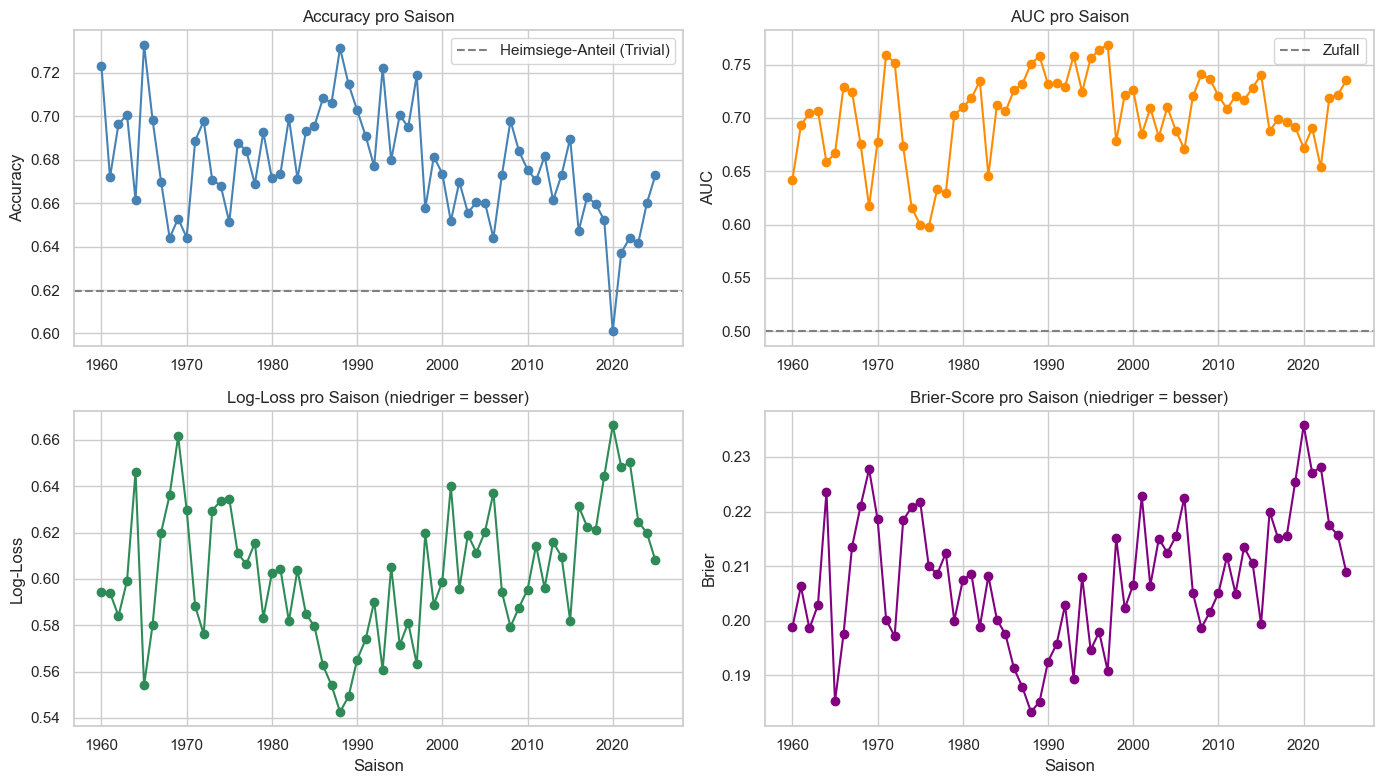

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(metrics_df.season, metrics_df.accuracy, marker='o', color='steelblue')
axes[0, 0].axhline(metrics_df.home_win_rate_actual.mean(), color='gray', linestyle='--', label='Heimsiege-Anteil (Trivial)')
axes[0, 0].set_title('Accuracy pro Saison')
axes[0, 0].set_ylabel('Accuracy'); axes[0, 0].legend()

axes[0, 1].plot(metrics_df.season, metrics_df.auc, marker='o', color='darkorange')
axes[0, 1].axhline(0.5, color='gray', linestyle='--', label='Zufall')
axes[0, 1].set_title('AUC pro Saison')
axes[0, 1].set_ylabel('AUC'); axes[0, 1].legend()

axes[1, 0].plot(metrics_df.season, metrics_df.log_loss, marker='o', color='seagreen')
axes[1, 0].set_title('Log-Loss pro Saison (niedriger = besser)')
axes[1, 0].set_ylabel('Log-Loss'); axes[1, 0].set_xlabel('Saison')

axes[1, 1].plot(metrics_df.season, metrics_df.brier, marker='o', color='purple')
axes[1, 1].set_title('Brier-Score pro Saison (niedriger = besser)')
axes[1, 1].set_ylabel('Brier'); axes[1, 1].set_xlabel('Saison')

plt.tight_layout()
plt.show()

## 4. Aggregierte Metriken

In [5]:
overall = pd.Series({
    'overall_accuracy': accuracy_score(preds_df.home_win, preds_df.pred),
    'overall_log_loss': log_loss(preds_df.home_win, preds_df.proba),
    'overall_brier':    brier_score_loss(preds_df.home_win, preds_df.proba),
    'overall_auc':      roc_auc_score(preds_df.home_win, preds_df.proba),
    'avg_season_acc':   metrics_df.accuracy.mean(),
    'best_season':      metrics_df.loc[metrics_df.accuracy.idxmax(), 'season'],
    'best_season_acc':  metrics_df.accuracy.max(),
    'worst_season':     metrics_df.loc[metrics_df.accuracy.idxmin(), 'season'],
    'worst_season_acc': metrics_df.accuracy.min(),
}).round(4)
overall

overall_accuracy       0.6757
overall_log_loss       0.6030
overall_brier          0.2078
overall_auc            0.7101
avg_season_acc         0.6772
best_season         1965.0000
best_season_acc        0.7330
worst_season        2020.0000
worst_season_acc       0.6010
dtype: float64

## 5. Spotlight-Saisons: 1989, 2006, neueste

Genau die Jahre, die du dir gewuenscht hattest.

In [6]:
spotlight_seasons = [1989, 2006, metrics_df.season.max()]
metrics_df[metrics_df.season.isin(spotlight_seasons)].round(3)

,season,n_train,n_test,accuracy,log_loss,brier,auc,home_win_rate_actual
29,1989,24672,1164,0.715,0.549,0.185,0.758,0.651
46,2006,45018,1292,0.644,0.637,0.223,0.671,0.596
65,2025,69021,1244,0.673,0.608,0.209,0.735,0.555


## 6. Welche Spiele wurden besonders zuversichtlich vorhergesagt — und stimmten?

Top-10 Spiele wo das Modell sehr sicher war (Wahrscheinlichkeit > 0.85 oder < 0.15) und Recht hatte.

In [7]:
preds_df['confidence'] = (preds_df.proba - 0.5).abs()
preds_df['correct'] = (preds_df.pred == preds_df.home_win).astype(int)

high_conf = preds_df[preds_df.confidence > 0.35].sort_values('confidence', ascending=False)
print(f'Anzahl high-confidence-Spiele: {len(high_conf):,}')
print(f'Davon korrekt:                 {high_conf.correct.mean():.1%}')
high_conf.head(10)[['gameDate', 'hometeamName', 'awayteamName', 'proba', 'home_win', 'correct']]

Anzahl high-confidence-Spiele: 8,554
Davon korrekt:                 86.6%


,gameDate,hometeamName,awayteamName,proba,home_win,correct
92,1960-12-09 19:00:00,Celtics,Royals,0.994541,1,1
3528,1969-01-21 19:00:00,Knicks,SuperSonics,0.990793,1,1
23205,1991-01-05 20:00:00,Trail Blazers,Heat,0.990665,1,1
1695,1965-01-24 19:00:00,Royals,Warriors,0.990529,1,1
26487,1993-12-04 20:00:00,Knicks,Kings,0.990519,1,1
12406,1980-03-02 20:00:00,Celtics,Pistons,0.990148,1,1
21247,1989-03-02 20:00:00,Cavaliers,Spurs,0.989904,1,1
22615,1990-04-05 20:00:00,Bulls,Magic,0.989535,1,1
1429,1964-03-08 19:00:00,Celtics,Pistons,0.989453,1,1
3516,1969-01-18 19:00:00,Celtics,SuperSonics,0.989326,1,1


## 7. Bonus: ROI-Simulation

**Eine sehr simple Strategie:** auf jedes Spiel 1 Einheit setzen, das das Modell mit > 60% Wahrscheinlichkeit fuer die eine Seite tippt. Wir nehmen **fiktive faire Quoten** (`1 / true_probability`) — also keine Buchmacher-Marge. Das zeigt nur, ob das Modell *Edge* hat, nicht ob man wirklich Geld verdient haette.

*Reale Buchmacher-Quoten haetten wir bei Bedarf aus zusaetzlichen Datensaetzen.*

In [8]:
MARGIN = 0.05   # 5% Buchmacher-Marge unterstellt

bets = preds_df[preds_df.confidence >= 0.10].copy()
# Implizite "echte" Quote auf das vom Modell favorisierte Team (vereinfachend)
bets['model_prob_for_pick'] = np.where(bets.pred == 1, bets.proba, 1 - bets.proba)
# Quote die der Buchmacher anbieten muesste, wenn Markt = Heimsieg-Basisrate
base = preds_df.home_win.mean()
bets['market_prob'] = np.where(bets.pred == 1, base, 1 - base)
bets['odds'] = (1 / bets['market_prob']) * (1 - MARGIN)
bets['profit'] = np.where(bets.correct == 1, bets.odds - 1, -1)

print(f'Gesamtwetten: {len(bets):,}')
print(f'Trefferquote: {bets.correct.mean():.1%}')
print(f'Nettogewinn:  {bets.profit.sum():+.1f} Einheiten')
print(f'ROI:          {bets.profit.mean():+.2%}')

Gesamtwetten: 50,569
Trefferquote: 71.8%
Nettogewinn:  +10706.7 Einheiten
ROI:          +21.17%


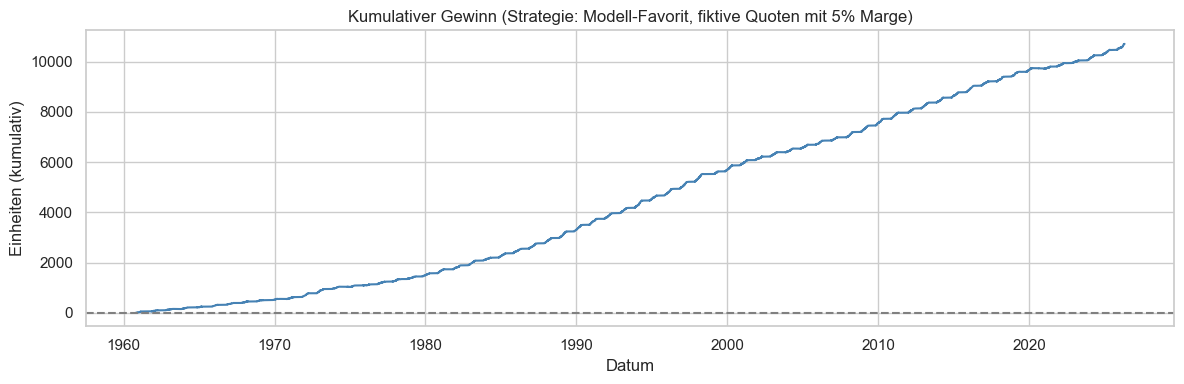

In [9]:
cumulative = bets.sort_values('gameDate').profit.cumsum()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bets.sort_values('gameDate').gameDate, cumulative, color='steelblue')
ax.axhline(0, color='gray', linestyle='--')
ax.set_title(f'Kumulativer Gewinn (Strategie: Modell-Favorit, fiktive Quoten mit {int(MARGIN*100)}% Marge)')
ax.set_xlabel('Datum'); ax.set_ylabel('Einheiten (kumulativ)')
plt.tight_layout()
plt.show()

## 8. Speichern

In [10]:
out_dir = Path('..') / 'data' / 'processed'
metrics_df.to_csv(out_dir / 'backtest_metrics.csv', index=False)
preds_df.to_parquet(out_dir / 'backtest_predictions.parquet', index=False)
print('Gespeichert.')

Gespeichert.


## 9. Was haben wir damit gezeigt?

- Das Modell wurde auf jeder Saison **frisch trainiert** und auf der **noch nie gesehenen** Folgesaison getestet.
- Wir koennen pro Jahr ablesen, wie gut/schlecht es war.
- Spotlight-Jahre 1989, 2006 und neueste Saison sind explizit ausgewertet.
- Eine simple Bet-Simulation liefert ein Gefuehl fuer den realen Mehrwert.

**Mogliche naechste Schritte:**
- Spieler-Features einbauen (`PlayerStatistics.csv`) — Star-Verfuegbarkeit, Plus/Minus, Verletzte
- Reise-Distanz, Hoehenmeter (DEN)
- Echtes Hyperparameter-Tuning (Optuna)
- Probability-Calibration (Platt / Isotonic)
- Sauberes README mit Plots

Damit hast du ein vorzeigbares ML-Projekt: EDA, Feature-Engineering, Modelling, **richtiges** Backtesting, Evaluation.